In [1]:
import pickle

import sys
sys.path.append('..')

import jax
import jax.numpy as jnp
import numpy as np
from matplotlib import pyplot as plt

from tools.geometry import generate_detector
from tools.generate import read_photon_data_from_photonsim
from tools.optimization.optimize import load_optimization_config, get_detector_params_from_config

print("Imports successful")

Imports successful


In [3]:
import pickle
import numpy as np

# --------------------------
# Load results
# --------------------------
results_file = '/sdf/data/neutrino/cjesus/lucid_output/paper_files/results_150k_nrays.pkl'

print(results_file)

with open(results_file, 'rb') as f:
    results_summary = pickle.load(f)

print(f"Loaded results from: {results_file}")
print(f"  Number of events: {results_summary['config']['n_events']}")

# --------------------------
# Extract event results
# --------------------------
all_event_results = results_summary['all_event_results']
n_events = len(all_event_results)

print(f"\nSuccessfully loaded {n_events} events")

# --------------------------
# Extract convergence histories
# --------------------------
def extract_histories(all_event_results):
    """
    Extract convergence histories for all events.
    
    Returns:
        Dictionary with arrays for each metric, shape (n_events, n_iterations)
    """
    histories = {
        'position_errors': [],
        'direction_errors': [],
        't0_errors': [],
        'energy_errors': [],
        'position_diff': [],
        'direction_diff': [],
        't0_diff': [],
        'energy_diff': [],
        'combined_losses': [],
        'vertex_losses': [],
        'counts_losses': [],
        'energy_losses': []
    }
    
    for event_result in all_event_results:
        opt_results = event_result['optimization_results']
        history = opt_results['history']
        
        histories['position_errors'].append(history['position_errors'])
        histories['direction_errors'].append(history['direction_errors'])
        histories['t0_errors'].append(history['t0_errors'])
        histories['energy_errors'].append(history['energy_errors'])
        histories['position_diff'].append(history['position_differences'])
        histories['direction_diff'].append(history['direction_differences'])
        histories['t0_diff'].append(history['t0_differences'])
        histories['energy_diff'].append(history['energy_differences'])
        histories['combined_losses'].append(history['combined_losses'])
        histories['vertex_losses'].append(history['vertex_losses'])
        histories['counts_losses'].append(history['counts_losses'])
        histories['energy_losses'].append(history['energy_losses'])
    
    # Convert to numpy arrays
    for key in histories:
        histories[key] = np.array(histories[key])
    
    return histories

histories = extract_histories(all_event_results)

# --------------------------
# Compute statistics
# --------------------------
def compute_statistics(data_array):
    """
    Compute mean, median, 68th percentile, and 90th percentile.
    
    Args:
        data_array: numpy array of shape (n_events, n_iterations)
    
    Returns:
        Dictionary with statistical measures
    """
    return {
        'mean': np.mean(data_array, axis=0),
        'median': np.median(data_array, axis=0),
        'percentile_68': np.percentile(data_array, 68, axis=0),
        'percentile_90': np.percentile(data_array, 90, axis=0)
    }

# Compute statistics for all metrics
stats = {}
for key in histories:
    stats[key] = compute_statistics(histories[key])

print("Computed statistics for all metrics")

n_events, n_iterations = histories['position_errors'].shape
print(f"Extracted histories: {n_events} events, {n_iterations} iterations each")

# --------------------------
# Convert energy errors → momentum errors (%)
# --------------------------
# Constants
m_mu = 105.658  # GeV (muon mass)
T_mu = 1050.0    # GeV (kinetic energy)
E_total = T_mu + m_mu
p_mu = np.sqrt(E_total**2 - m_mu**2)
conversion_factor = E_total / p_mu

print(f"\n--- Energy → Momentum conversion ---")
print(f"Muon mass = {m_mu:.6f} GeV")
print(f"Kinetic energy = {T_mu:.3f} GeV")
print(f"Total energy = {E_total:.6f} GeV")
print(f"Momentum = {p_mu:.6f} GeV")
print(f"Conversion factor (Δp/p)/(ΔE/E) = {conversion_factor:.8f}")

# If energy_errors are ABSOLUTE [GeV]:
momentum_errors_percent = (conversion_factor * (histories['energy_errors'] / E_total)) * 100

# If instead they are already RELATIVE (ΔE/E), comment the line above and use:
# momentum_errors_percent = conversion_factor * histories['energy_errors'] * 100

# Store and compute statistics
histories['momentum_errors_percent'] = momentum_errors_percent
stats['momentum_errors_percent'] = compute_statistics(momentum_errors_percent)

print("\nConverted energy errors into momentum errors (in %) and computed statistics.")
print(f"Example: mean momentum error at last iteration = {stats['momentum_errors_percent']['mean'][-1]:.4f}%")


/sdf/data/neutrino/cjesus/lucid_output/paper_files/results_150k_nrays.pkl
Loaded results from: /sdf/data/neutrino/cjesus/lucid_output/paper_files/results_150k_nrays.pkl
  Number of events: 500

Successfully loaded 500 events
Computed statistics for all metrics
Extracted histories: 500 events, 300 iterations each

--- Energy → Momentum conversion ---
Muon mass = 105.658000 GeV
Kinetic energy = 1050.000 GeV
Total energy = 1155.658000 GeV
Momentum = 1150.817883 GeV
Conversion factor (Δp/p)/(ΔE/E) = 1.00420581

Converted energy errors into momentum errors (in %) and computed statistics.
Example: mean momentum error at last iteration = 1.1724%


In [4]:
import pandas as pd
import numpy as np

ci_level_val = 90
def bootstrap_percentile_ci(data, percentile=68, n_bootstrap=10000, ci_level=ci_level_val):
    """Bootstrap confidence intervals for a percentile estimate."""
    bootstrap_estimates = []
    n = len(data)
    
    for _ in range(n_bootstrap):
        bootstrap_sample = np.random.choice(data, size=n, replace=True)
        bootstrap_estimates.append(np.percentile(bootstrap_sample, percentile))
    
    bootstrap_estimates = np.array(bootstrap_estimates)
    
    alpha = (100 - ci_level) / 2
    ci_lower = np.percentile(bootstrap_estimates, alpha)
    ci_upper = np.percentile(bootstrap_estimates, 100 - alpha)
    
    return {
        'estimate': np.percentile(data, percentile),
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'std_error': np.std(bootstrap_estimates)
    }

# Number of events and iterations
n_iterations, n_events = histories['position_errors'].shape
n_iter = -1

# Set seed for reproducibility
np.random.seed(42)

# --- Last iteration data ---
distance_data = histories['position_errors'][:, n_iter] * 100  # convert to cm
angle_data = histories['direction_errors'][:, n_iter]
t0_data = histories['t0_errors'][:, n_iter]
momentum_data = histories['momentum_errors_percent'][:, n_iter]

# --- Bootstrap 68% percentiles ---
distance_boot = bootstrap_percentile_ci(distance_data, percentile=68)
angle_boot = bootstrap_percentile_ci(angle_data, percentile=68)
t0_boot = bootstrap_percentile_ci(t0_data, percentile=68)
momentum_boot = bootstrap_percentile_ci(momentum_data, percentile=68)

# --- Build table ---
data = {
    "Distance error (cm)": [
        f"{distance_boot['estimate']:.2f} [{distance_boot['ci_lower']:.2f}, {distance_boot['ci_upper']:.2f}]"
    ],
    "Angle error (°)": [
        f"{angle_boot['estimate']:.2f} [{angle_boot['ci_lower']:.2f}, {angle_boot['ci_upper']:.2f}]"
    ],
    "t0 error (ns)": [
        f"{t0_boot['estimate']:.2f} [{t0_boot['ci_lower']:.2f}, {t0_boot['ci_upper']:.2f}]"
    ],
    "Momentum 68% error (%)": [
        f"{momentum_boot['estimate']:.2f} [{momentum_boot['ci_lower']:.2f}, {momentum_boot['ci_upper']:.2f}]"
    ]
}

index = ["LUCiD"]
df = pd.DataFrame(data, index=index)

print("\n" + "="*80)
print(f"68% METRICS WITH {ci_level_val:.0f}% CONFIDENCE INTERVALS")
print("="*80)
print(df.to_string())
print("="*80 + "\n")

# Optional: Print detailed statistics
print("Detailed Bootstrap Statistics:")
print("-" * 80)
for name, boot_result in [
    ("Distance error (cm)", distance_boot),
    ("Angle error (°)", angle_boot),
    ("t0 error (ns)", t0_boot),
    ("Momentum 68% error (%)", momentum_boot)
]:
    print(f"{name}:")
    print(f"  Estimate: {boot_result['estimate']:.4f}")
    print(f"  {ci_level_val}% CI: [{boot_result['ci_lower']:.4f}, {boot_result['ci_upper']:.4f}]")
    print(f"  Std Error: {boot_result['std_error']:.4f}")
    print()


68% METRICS WITH 90% CONFIDENCE INTERVALS
        Distance error (cm)    Angle error (°)      t0 error (ns) Momentum 68% error (%)
LUCiD  18.02 [17.39, 18.91]  1.06 [1.00, 1.13]  0.43 [0.41, 0.47]      1.40 [1.29, 1.49]

Detailed Bootstrap Statistics:
--------------------------------------------------------------------------------
Distance error (cm):
  Estimate: 18.0172
  90% CI: [17.3947, 18.9086]
  Std Error: 0.4710

Angle error (°):
  Estimate: 1.0566
  90% CI: [1.0021, 1.1257]
  Std Error: 0.0349

t0 error (ns):
  Estimate: 0.4320
  90% CI: [0.4089, 0.4650]
  Std Error: 0.0172

Momentum 68% error (%):
  Estimate: 1.3968
  90% CI: [1.2861, 1.4949]
  Std Error: 0.0624



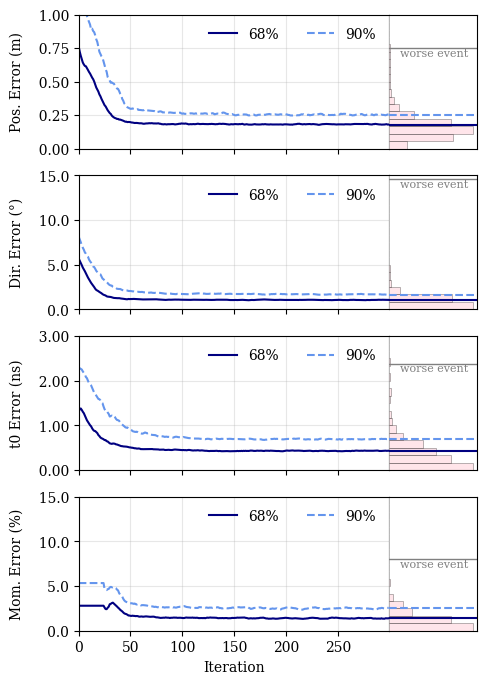

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
    'font.size': 10
})


def create_convergence_subplot(
    ax, hist_ax, histories, metric_name, ylabel,
    use_log=False, hist_bins=18, max_y=1.0, energy_error_threshold=5000.0
):
    """Helper to draw one convergence subplot and its histogram."""

    # --- Mask by energy error threshold ---
    if 'energy_errors' in histories:
        energy_errors_percent = histories['energy_errors'] / histories['energy_errors'].mean() * 100
    elif 'momentum_errors_percent' in histories:
        energy_errors_percent = histories['momentum_errors_percent']
    else:
        raise KeyError("No 'energy_errors' or 'momentum_errors_percent' found in histories.")

    mask = np.abs(energy_errors_percent[:, -1]) <= energy_error_threshold
    masked_histories = {k: v[mask] for k, v in histories.items()}

    # --- Recompute statistics ---
    stats = {}
    for key, arr in masked_histories.items():
        stats[key] = {
            'mean': np.mean(arr, axis=0),
            'median': np.median(arr, axis=0),
            'percentile_68': np.percentile(arr, 68, axis=0),
            'percentile_90': np.percentile(arr, 90, axis=0),
            'worse': np.percentile(arr, 99.99, axis=0),
        }

    n_iterations = len(stats[metric_name]['mean'])
    iterations = np.arange(n_iterations)

    # --- Colors and style ---
    col_p68, col_p90 = 'navy', 'cornflowerblue'
    lw, alpha = 1.5, 1.0

    # --- Main plot ---
    ax.plot(iterations, stats[metric_name]['percentile_68'],
            color=col_p68, lw=lw, linestyle='-', label='68%', alpha=alpha)
    ax.plot(iterations, stats[metric_name]['percentile_90'],
            color=col_p90, lw=lw, linestyle='--', label='90%', alpha=alpha)

    ax.set_ylabel(ylabel)
    ax.set_xlim(0, n_iterations - 1)
    ax.set_ylim(0, max_y)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', frameon=False, ncol=3)

    if metric_name in ('position_errors', 't0_errors'):
        ax.yaxis.set_major_formatter(FormatStrFormatter('%6.2f'))
    else:
        ax.yaxis.set_major_formatter(FormatStrFormatter('%6.1f'))

    if use_log:
        ax.set_yscale('log')

    # --- Histogram on the right ---
    last_iter_values = masked_histories[metric_name][:, -1]
    hist_ax.hist(last_iter_values, bins=hist_bins, range=[0, max_y],
                 orientation='horizontal', color='pink', alpha=0.4,
                 edgecolor='black', linewidth=0.5)

    for key, color, style in [
        ('percentile_68', col_p68, '-'),
        ('percentile_90', col_p90, '--'),
    ]:
        hist_ax.axhline(y=stats[metric_name][key][-1], color=color,
                        lw=lw, linestyle=style, alpha=alpha)

    yval = stats[metric_name]['worse'][-1]
    hist_ax.axhline(y=yval, color='gray', lw=1, linestyle='-', alpha=alpha)
    hist_ax.text(0.9, yval, 'worse event', color='gray', alpha=alpha,
                 ha='right', va='top', fontsize=8, transform=hist_ax.get_yaxis_transform())

    hist_ax.set_yticks([])
    hist_ax.set_xticks([])
    hist_ax.set_ylim(ax.get_ylim())
    sns.despine(ax=hist_ax, left=True, bottom=False, right=False, top=False)


# ---------------------------------------------------
# Combined multi-panel figure
# ---------------------------------------------------

def create_convergence_figure(histories):
    metrics = [
        ('position_errors', 'Pos. Error (m)', 1.0),
        ('direction_errors', 'Dir. Error (°)', 15.0),
        ('t0_errors', 't0 Error (ns)', 3.0),
        ('momentum_errors_percent', 'Mom. Error (%)', 15.0)
    ]

    fig, axs = plt.subplots(len(metrics), 1, figsize=(4, 8), sharex=True)
    #fig.subplots_adjust(right=1., hspace=0.25)

    # Create a right-hand histogram axis for each main subplot
    hist_axes = []
    for ax in axs:
        bbox = ax.get_position()
        hist_ax = fig.add_axes([
            bbox.x1 + 0.001, bbox.y0, 0.22, bbox.height
        ])
        hist_axes.append(hist_ax)

    for (metric, ylabel, max_y), ax, hist_ax in zip(metrics, axs, hist_axes):
        create_convergence_subplot(ax, hist_ax, histories, metric, ylabel, max_y=max_y)

    axs[-1].set_xlabel('Iteration')

    #sns.despine(fig)
    return fig


# Example usage:
fig = create_convergence_figure(histories)
plt.savefig('figures/convergence_all_metrics.pdf', bbox_inches='tight')
plt.show()



==== Absolute 68th percentile containment ====
Longitudinal |Δr‖|_68 = 0.126534
Transverse   |Δr⊥|_68 = 0.120392

Longitudinal bias (signed): 0.0684237
Transverse bias (t1, t2):  (-0.00205246, -0.00517093); |bias|=0.00556337
Longitudinal resolution:    0.12035
Transverse resolution t1:   0.0818498
Transverse resolution t2:   0.0856846
Radial |Δr⊥| spread (σ):    0.0608272  [not a bias metric]


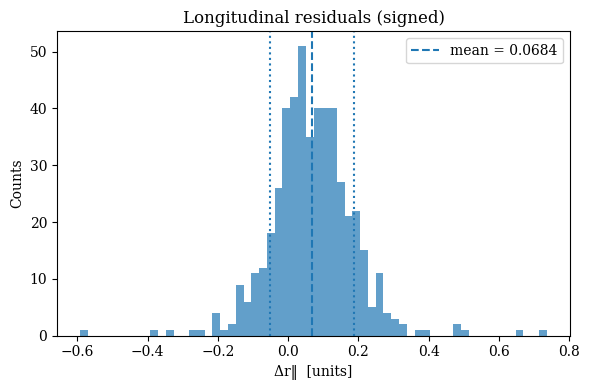

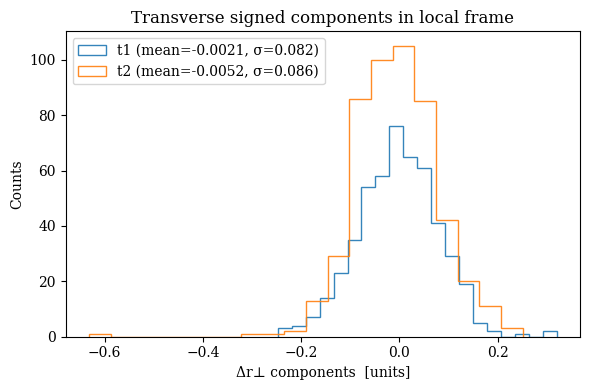

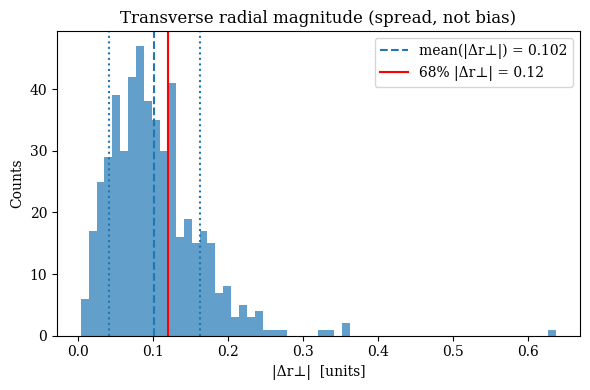

In [7]:
import numpy as np
import matplotlib.pyplot as plt

max_events = -1

# --- Inputs ---
delta_pos = histories['position_diff'][:max_events, -1, :]  # reco - true, shape (N,3)
true_dir  = np.array([e['event_data']['true_direction'] for e in all_event_results[0:max_events]])

# --- Normalize directions ---
norms = np.linalg.norm(true_dir, axis=1, keepdims=True)
dir_unit = true_dir / np.clip(norms, 1e-12, None)

# --- Longitudinal / transverse decomposition ---
delta_long = np.einsum('ij,ij->i', delta_pos, dir_unit)                 # signed scalar
delta_trans_vec = delta_pos - delta_long[:, None] * dir_unit            # vector in plane
delta_trans_mag = np.linalg.norm(delta_trans_vec, axis=1)               # radial magnitude (>=0)

# --- Build per-event transverse basis (v1, v2) ---
ref = np.tile(np.array([1.0, 0.0, 0.0]), (dir_unit.shape[0], 1))
collinear = np.abs(np.sum(dir_unit * ref, axis=1)) > 0.9
ref[collinear] = np.array([0.0, 1.0, 0.0])

v1 = ref - (np.einsum('ij,ij->i', ref, dir_unit))[:, None] * dir_unit
v1 /= np.clip(np.linalg.norm(v1, axis=1, keepdims=True), 1e-12, None)
v2 = np.cross(dir_unit, v1)

# Signed transverse components in local frame
t1 = np.einsum('ij,ij->i', delta_trans_vec, v1)
t2 = np.einsum('ij,ij->i', delta_trans_vec, v2)

# --- Biases (means) ---
bias_long = np.mean(delta_long)
bias_t1   = np.mean(t1)
bias_t2   = np.mean(t2)
bias_trans_vector_mag = np.hypot(bias_t1, bias_t2)

# --- Resolutions (stds) ---
res_long = np.std(delta_long, ddof=0)
res_t1   = np.std(t1, ddof=0)
res_t2   = np.std(t2, ddof=0)
res_trans_mag = np.std(delta_trans_mag, ddof=0)

# --- 68th percentile containment (from 0 to 68%) ---
abs_long = np.abs(delta_long)
abs_trans = delta_trans_mag
p68_long = np.percentile(abs_long, 68)
p68_trans = np.percentile(abs_trans, 68)

print("\n==== Absolute 68th percentile containment ====")
print(f"Longitudinal |Δr‖|_68 = {p68_long:.6g}")
print(f"Transverse   |Δr⊥|_68 = {p68_trans:.6g}")
print("==============================================\n")

# --- Bias/resolution summary ---
print(f"Longitudinal bias (signed): {bias_long:.6g}")
print(f"Transverse bias (t1, t2):  ({bias_t1:.6g}, {bias_t2:.6g}); |bias|={bias_trans_vector_mag:.6g}")
print(f"Longitudinal resolution:    {res_long:.6g}")
print(f"Transverse resolution t1:   {res_t1:.6g}")
print(f"Transverse resolution t2:   {res_t2:.6g}")
print(f"Radial |Δr⊥| spread (σ):    {res_trans_mag:.6g}  [not a bias metric]")

# --- Histograms ---
# 1) Longitudinal (signed)
plt.figure(figsize=(6,4))
plt.hist(delta_long, bins=60, histtype='stepfilled', alpha=0.7)
plt.axvline(bias_long, linestyle='--', label=f"mean = {bias_long:.3g}")
plt.axvline(bias_long + res_long, linestyle=':')
plt.axvline(bias_long - res_long, linestyle=':')
plt.xlabel("Δr‖  [units]")
plt.ylabel("Counts")
plt.title("Longitudinal residuals (signed)")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Transverse signed components t1 and t2
plt.figure(figsize=(6,4))
plt.hist(t1, bins=20, histtype='step', alpha=0.9, label=f"t1 (mean={bias_t1:.2g}, σ={res_t1:.2g})")
plt.hist(t2, bins=20, histtype='step', alpha=0.9, label=f"t2 (mean={bias_t2:.2g}, σ={res_t2:.2g})")
plt.xlabel("Δr⊥ components  [units]")
plt.ylabel("Counts")
plt.title("Transverse signed components in local frame")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Radial magnitude (for spread only)
plt.figure(figsize=(6,4))
plt.hist(delta_trans_mag, bins=60, histtype='stepfilled', alpha=0.7)
plt.axvline(np.mean(delta_trans_mag), linestyle='--', label=f"mean(|Δr⊥|) = {np.mean(delta_trans_mag):.3g}")
plt.axvline(np.mean(delta_trans_mag) + res_trans_mag, linestyle=':')
plt.axvline(np.mean(delta_trans_mag) - res_trans_mag, linestyle=':')
plt.axvline(p68_trans, color='r', linestyle='-', label=f"68% |Δr⊥| = {p68_trans:.3g}")
plt.xlabel("|Δr⊥|  [units]")
plt.ylabel("Counts")
plt.title("Transverse radial magnitude (spread, not bias)")
plt.legend()
plt.tight_layout()
plt.show()


t0 bias       : 0.0488
t0 resolution : 0.4669
Energy bias   : 1.7293
Energy resol. : 17.6776


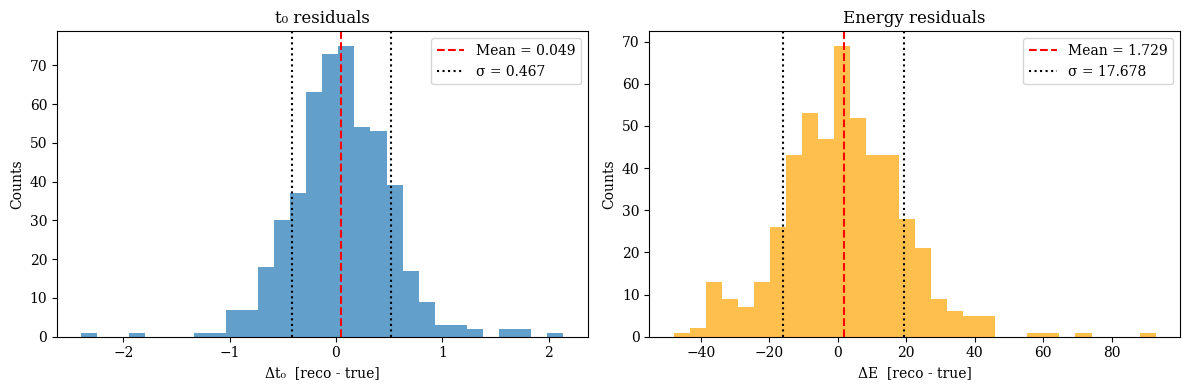

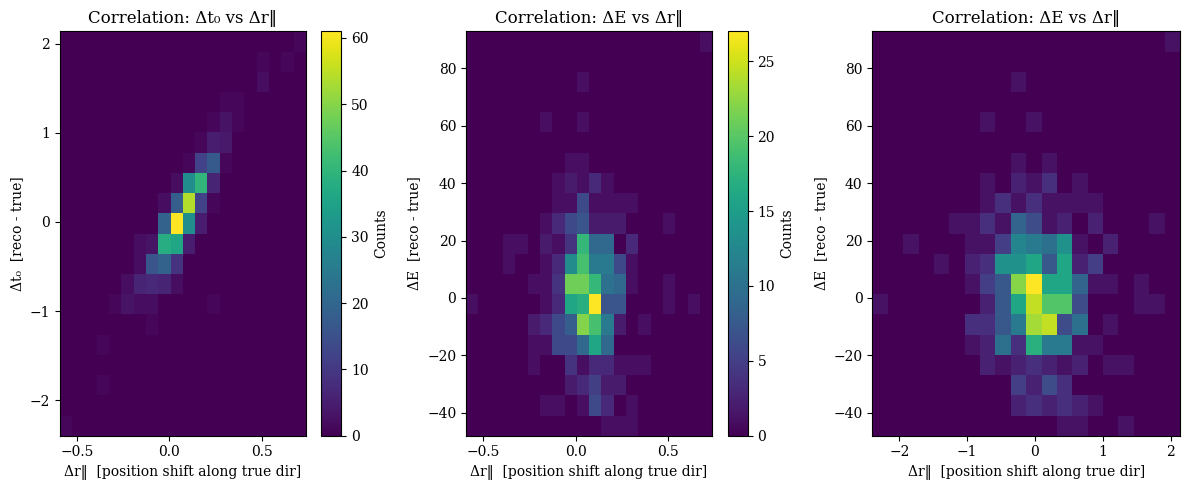

In [15]:
import numpy as np
import matplotlib.pyplot as plt

max_events = -1

# --- Extract relevant quantities ---
# Position difference (reco - true): shape (n_events, n_iterations, 3)
pos_diff = histories['position_diff'][:max_events, -1, :]  # last iteration
t0_diff  = histories['t0_diff'][:max_events, -1]           # (n_events,)
energy_diff = histories['energy_diff'][:max_events, -1]    # (n_events,)

# True directions: shape (n_events, 3)
true_dir = np.array([e['event_data']['true_direction'] for e in all_event_results[:max_events]])

# --- Normalize directions ---
norms = np.linalg.norm(true_dir, axis=1, keepdims=True)
dir_unit = true_dir / np.clip(norms, 1e-12, None)

# --- Longitudinal position shift (signed projection) ---
delta_long = np.einsum('ij,ij->i', pos_diff, dir_unit)

# --- Biases and resolutions ---
bias_t0 = np.mean(t0_diff)
res_t0  = np.std(t0_diff)
bias_E  = np.mean(energy_diff)
res_E   = np.std(energy_diff)

print(f"t0 bias       : {bias_t0:.4f}")
print(f"t0 resolution : {res_t0:.4f}")
print(f"Energy bias   : {bias_E:.4f}")
print(f"Energy resol. : {res_E:.4f}")

# --- Histograms ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# t0 residuals
axes[0].hist(t0_diff, bins=30, histtype='stepfilled', alpha=0.7)
axes[0].axvline(bias_t0, color='r', linestyle='--', label=f'Mean = {bias_t0:.3f}')
axes[0].axvline(bias_t0 + res_t0, color='k', linestyle=':', label=f'σ = {res_t0:.3f}')
axes[0].axvline(bias_t0 - res_t0, color='k', linestyle=':')
axes[0].set_xlabel("Δt₀  [reco - true]")
axes[0].set_ylabel("Counts")
axes[0].set_title("t₀ residuals")
axes[0].legend()

# Energy residuals
axes[1].hist(energy_diff, bins=30, histtype='stepfilled', alpha=0.7, color='orange')
axes[1].axvline(bias_E, color='r', linestyle='--', label=f'Mean = {bias_E:.3f}')
axes[1].axvline(bias_E + res_E, color='k', linestyle=':', label=f'σ = {res_E:.3f}')
axes[1].axvline(bias_E - res_E, color='k', linestyle=':')
axes[1].set_xlabel("ΔE  [reco - true]")
axes[1].set_ylabel("Counts")
axes[1].set_title("Energy residuals")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Correlations ---
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Δt0 vs Δr‖
h1 = axes[0].hist2d(delta_long, t0_diff, bins=(20, 20), cmap='viridis')
axes[0].set_xlabel("Δr‖  [position shift along true dir]")
axes[0].set_ylabel("Δt₀  [reco - true]")
axes[0].set_title("Correlation: Δt₀ vs Δr‖")
plt.colorbar(h1[3], ax=axes[0], label='Counts')

# ΔE vs Δr‖
h2 = axes[1].hist2d(delta_long, energy_diff, bins=(20, 20), cmap='viridis')
axes[1].set_xlabel("Δr‖  [position shift along true dir]")
axes[1].set_ylabel("ΔE  [reco - true]")
axes[1].set_title("Correlation: ΔE vs Δr‖")
plt.colorbar(h2[3], ax=axes[1], label='Counts')

h3 = axes[2].hist2d(t0_diff, energy_diff, bins=(20, 20), cmap='viridis')
axes[2].set_xlabel("Δr‖  [position shift along true dir]")
axes[2].set_ylabel("ΔE  [reco - true]")
axes[2].set_title("Correlation: ΔE vs Δr‖")
#plt.colorbar(h3[2], ax=axes[2], label='Counts')

plt.tight_layout()
plt.show()


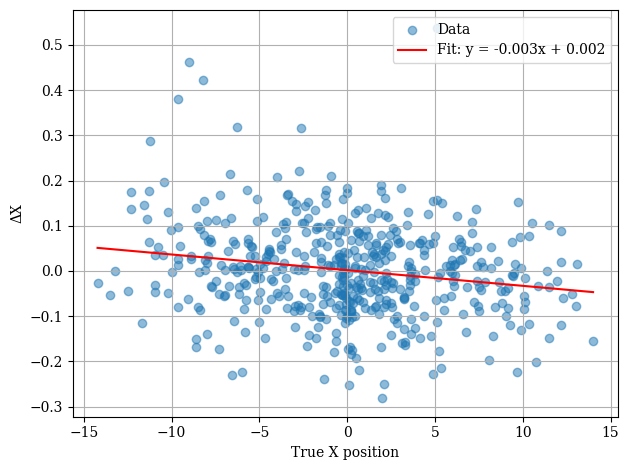

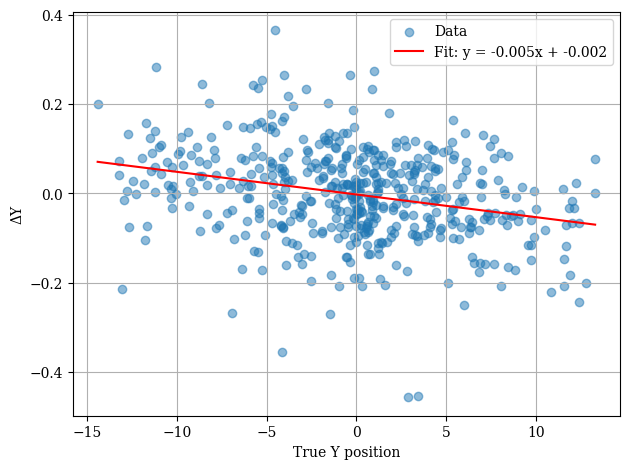

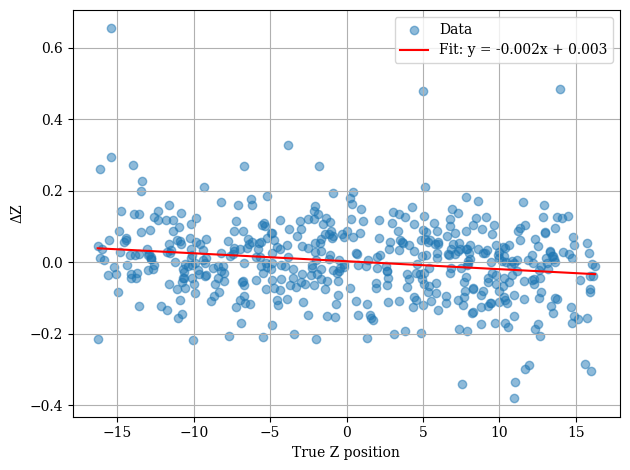

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Extract true positions
x_pos = [all_event_results[i]['event_data']['true_position'][0] for i in range(len(all_event_results))]
y_pos = [all_event_results[i]['event_data']['true_position'][1] for i in range(len(all_event_results))]
z_pos = [all_event_results[i]['event_data']['true_position'][2] for i in range(len(all_event_results))]

# Extract true directions (looks like you used [2] for all — double-check if that's intentional)
x_dir = [all_event_results[i]['event_data']['true_direction'][0] for i in range(len(all_event_results))]
y_dir = [all_event_results[i]['event_data']['true_direction'][1] for i in range(len(all_event_results))]
z_dir = [all_event_results[i]['event_data']['true_direction'][2] for i in range(len(all_event_results))]

# Helper function to add scatter + linear fit
def scatter_with_fit(x, y, xlabel, ylabel):
    plt.figure()
    plt.scatter(x, y, alpha=0.5, label='Data')

    # Linear fit
    coeffs = np.polyfit(x, y, 1)  # degree 1 polynomial
    fit_fn = np.poly1d(coeffs)
    
    # Sort x for plotting a smooth line
    x_sorted = np.linspace(min(x), max(x), 200)
    plt.plot(x_sorted, fit_fn(x_sorted), 'r-', label=f'Fit: y = {coeffs[0]:.3f}x + {coeffs[1]:.3f}')
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot each component with a fit
good_idx = histories['energy_diff'][:,-1]<100
scatter_with_fit(np.array(x_pos)[good_idx], histories['position_diff'][:,-1,0][good_idx], 'True X position', 'ΔX')
scatter_with_fit(np.array(y_pos)[good_idx], histories['position_diff'][:,-1,1][good_idx], 'True Y position', 'ΔY')
scatter_with_fit(np.array(z_pos)[good_idx], histories['position_diff'][:,-1,2][good_idx], 'True Z position', 'ΔZ')

#np.std(histories['position_diff'][:,-1,0][good_idx])*np.sqrt(3), np.std(histories['position_diff'][:,-1,1][good_idx])*np.sqrt(3), np.std(histories['position_diff'][:,-1,2][good_idx])*np.sqrt(3)

68% percentile of distance = 0.0818


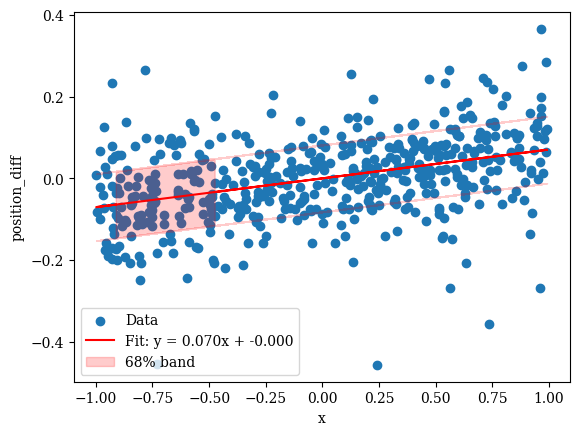

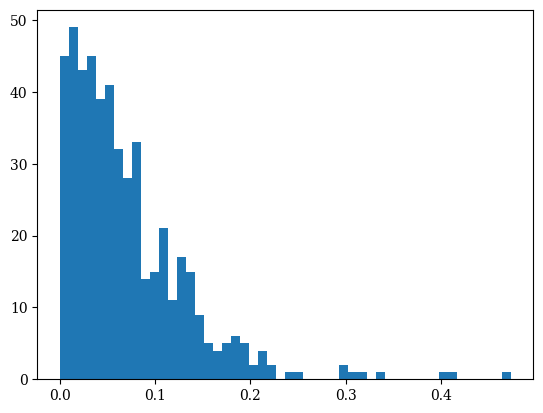

In [25]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array(y_dir)
y = histories['position_diff'][:, -1, 1]

# --- 1. Linear fit ---
coeffs = np.polyfit(x, y, 1)   # slope and intercept
fit_fn = np.poly1d(coeffs)
y_fit = fit_fn(x)

# --- 2. Distances (residuals) ---
residuals = y - y_fit
distances = np.abs(residuals)  # absolute distances to the line

# --- 3. 68% percentile ---
p68 = np.percentile(distances, 68)  # 68% measured from 0

print(f"68% percentile of distance = {p68:.4f}")

# --- Plot ---
plt.scatter(x, y, label='Data')
plt.plot(x, y_fit, 'r-', label=f'Fit: y = {coeffs[0]:.3f}x + {coeffs[1]:.3f}')
plt.fill_between(x, y_fit - p68, y_fit + p68, color='red', alpha=0.2, label='68% band')
plt.legend()
plt.xlabel("x")
plt.ylabel("position_diff")
plt.show()

_ = plt.hist(np.abs(residuals),bins=50)

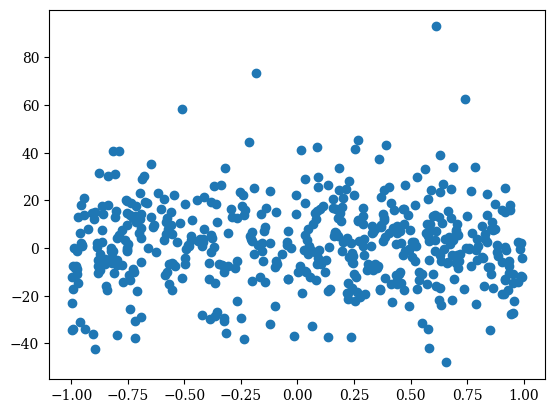

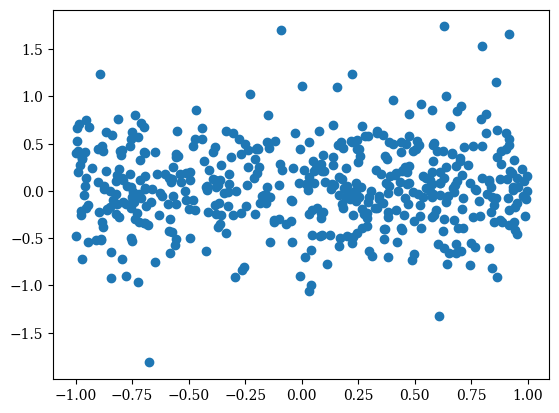

In [21]:
mask = (np.abs(histories['energy_diff'][:,-1]) < 100.0)
plt.scatter(np.array(x_dir)[mask], histories['energy_diff'][:,-1][mask])

plt.show()
mask = (np.abs(histories['t0_diff'][:,-1]) < 2.0)
plt.scatter(np.array(x_dir)[mask], histories['t0_diff'][:,-1][mask])

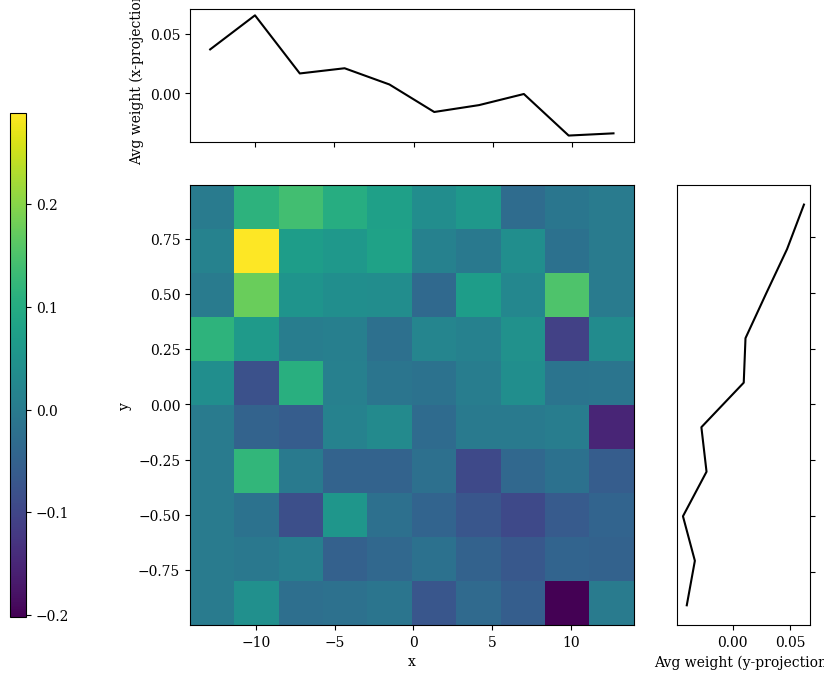

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

def plot_avg_weight_2d(x, y, w, bins=50, range=None):
    """
    Plot a 2D map of average weights per bin, with 1D projections.
    
    Parameters
    ----------
    x, y : array-like
        Coordinates of data points.
    w : array-like
        Weights to average per bin.
    bins : int or [int, int] or [array, array], optional
        Binning specification (as in np.histogram2d).
    range : [[xmin, xmax], [ymin, ymax]], optional
        Range of bins (as in np.histogram2d).
    """
    # Compute histograms
    sum_w, xedges, yedges = np.histogram2d(x, y, weights=w, bins=bins, range=range)
    counts, _, _ = np.histogram2d(x, y, bins=[xedges, yedges])
    avg_w = np.divide(sum_w, counts, out=np.zeros_like(sum_w), where=counts > 0)

    # 1D projections (averaged over the other axis)
    avg_x = np.divide(sum_w.sum(axis=1), counts.sum(axis=1), out=np.zeros_like(sum_w.sum(axis=1)), where=counts.sum(axis=1) > 0)
    avg_y = np.divide(sum_w.sum(axis=0), counts.sum(axis=0), out=np.zeros_like(sum_w.sum(axis=0)), where=counts.sum(axis=0) > 0)

    # Mesh for 2D plot
    X, Y = np.meshgrid(xedges, yedges)

    # Layout: 2x2 with asymmetric margins
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(
        2, 2,
        width_ratios=[4, 1.2],
        height_ratios=[1.2, 4],
        wspace=0.15,
        hspace=0.15
    )

    # --- Top: X projection ---
    ax_top = plt.subplot(gs[0, 0])
    ax_top.plot((xedges[:-1] + xedges[1:]) / 2, avg_x, color='black')
    ax_top.set_ylabel('Avg weight (x-projection)')
    ax_top.tick_params(labelbottom=False)

    # --- Main 2D plot ---
    ax_main = plt.subplot(gs[1, 0])
    pcm = ax_main.pcolormesh(X, Y, avg_w.T, shading='auto')
    ax_main.set_xlabel('x')
    ax_main.set_ylabel('y')

    # --- Right: Y projection (on the right side) ---
    ax_right = plt.subplot(gs[1, 1])
    ax_right.plot(avg_y, (yedges[:-1] + yedges[1:]) / 2, color='black')
    ax_right.set_xlabel('Avg weight (y-projection)')
    ax_right.tick_params(labelleft=False)
    ax_right.yaxis.set_label_position("right")
    ax_right.yaxis.tick_right()

    # --- Colorbar (on the left side, to avoid overlap) ---
    cax = fig.add_axes([-0.1, 0.12, 0.02, 0.63])  # [left, bottom, width, height]
    cbar = fig.colorbar(pcm, cax=cax, orientation='vertical')
    #cbar.set_label('Average weight per bin')

    plt.show()

# Example usage:
plot_avg_weight_2d(x_pos, x_dir, histories['position_diff'][:, -1, 0], bins=[10, 10])


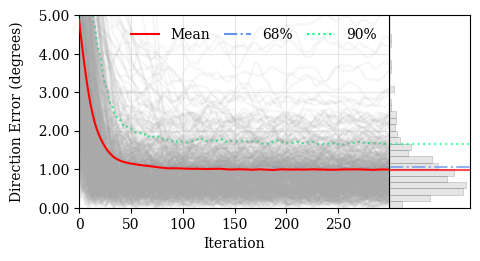

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

def create_convergence_plot_v2(
    histories, stats, metric_name, ylabel, title,
    use_log=False, figsize=(4, 2.5),
    show_histogram=True, hist_bins=30, hist_width=0.2, max_y=1.0
):
    fig, ax = plt.subplots(figsize=figsize)
    n_iterations = len(stats[metric_name]['mean'])
    n_events = len(histories[metric_name])
    iterations = np.arange(n_iterations)

    col_mean, col_median, col_p68, col_p90 = np.array([
        'red',
        'darkorange', 
        'cornflowerblue',
        'springgreen',
    ])


    
    lw = 1.5

    for h in histories[metric_name]:
        ax.plot(iterations, h, alpha=0.1, color='darkgray')

    # Plot main curves
    ax.plot(iterations, stats[metric_name]['mean'],
            color=col_mean, linewidth=lw, label=f'Mean', zorder=3)
    # ax.plot(iterations, stats[metric_name]['median'],
    #         color=col_median, linewidth=lw, linestyle='--', label='Median', zorder=2)
    ax.plot(iterations, stats[metric_name]['percentile_68'],
            color=col_p68, linewidth=lw, linestyle='-.', label='68%', zorder=1)
    ax.plot(iterations, stats[metric_name]['percentile_90'],
            color=col_p90, linewidth=lw, linestyle=':', label='90%', zorder=1)

    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, n_iterations - 1)
    #ax.set_xlim(0, 20)
    ax.set_ylim(0, max_y)
    
    # Format y-axis to always show consistent number of decimal places
    # Use consistent formatting to ensure histogram alignment across all plots
    # Format: 3 digits before decimal, 2 after (e.g., "100.00", "  5.00", "  1.50")
    ax.yaxis.set_major_formatter(FormatStrFormatter('%6.2f'))
    
    ax.legend(loc='best', framealpha=0., frameon=False, ncol=3, handlelength=2.0, columnspacing=1.0)

    if use_log:
        ax.set_yscale('log')

    # --- Optional histogram on the right ---
    if show_histogram:
        # Create a small inset axis on the right
        bbox = ax.get_position()
        hist_ax = fig.add_axes([
            bbox.x1 + 0.003,  # X position (a bit right of main plot)
            bbox.y0,         # Same Y position
            0.2,#hist_width * bbox.width,  # Width relative to main axis
            bbox.height       # Same height
        ])

        # Extract values at last iteration
        last_iter_values = histories[metric_name][:, -1]

        # Plot histogram horizontally
        hist_ax.hist(last_iter_values, bins=hist_bins, range=[0, max_y], orientation='horizontal',
                     color='gray', alpha=0.2, edgecolor='black', linewidth=0.5)

        # Add horizontal lines for statistics at last iteration
        last_mean = stats[metric_name]['mean'][-1]
        last_median = stats[metric_name]['median'][-1]
        last_p68 = stats[metric_name]['percentile_68'][-1]
        last_p90 = stats[metric_name]['percentile_90'][-1]
        
        # Plot horizontal lines with same colors and styles as main plot
        hist_ax.axhline(y=last_mean, color=col_mean, linewidth=lw, linestyle='-', alpha=0.7)
        # hist_ax.axhline(y=last_median, color=col_median, linewidth=lw, linestyle='--', alpha=0.7)
        hist_ax.axhline(y=last_p68, color=col_p68, linewidth=lw, linestyle='-.', alpha=0.7)
        hist_ax.axhline(y=last_p90, color=col_p90, linewidth=lw, linestyle=':', alpha=0.7)

        hist_ax.set_yticks([])  # No y ticks
        hist_ax.set_xticks([])
        #hist_ax.set_title('Final dist.', fontsize=8)
        hist_ax.set_ylim(ax.get_ylim())  # Match vertical scale
        sns.despine(ax=hist_ax, left=True, bottom=False, right=False, top=False)
        #sns.despine(ax=hist_ax, left=True, bottom=True, right=True, top=True)
        ax.grid(True, alpha=0.3)
    #plt.tight_layout()
    return fig, ax

# fig, ax = create_convergence_plot_v2(
#     histories, stats, 'position_errors',
#     ylabel='Position Error (m)',
#     title='Position Error Convergence',
#     show_histogram=True, max_y=10.0
# )
# plt.savefig('figures/convergence_position_error_with_hist.png', dpi=150, bbox_inches='tight')
# plt.show()


fig, ax = create_convergence_plot_v2(
    histories, stats, 'direction_errors',
    ylabel='Direction Error (degrees)',
    title='Direction Error Convergence',
    show_histogram=True, max_y=5.0
)
plt.savefig('figures/convergence_direction_error.png', dpi=150, bbox_inches='tight')
plt.show()

# # t0 error convergence
# fig, ax = create_convergence_plot_v2(
#     histories, stats, 't0_errors',
#     ylabel='t0 Error (ns)',
#     title='t0 Error Convergence',
#     show_histogram=True, max_y=100.0
# )
# plt.savefig('figures/convergence_t0_error.png', dpi=150, bbox_inches='tight')
# plt.show()

# # Momentum error convergence
# fig, ax = create_convergence_plot_v2(
#     histories, stats, 'momentum_errors_percent',
#     ylabel='Momentum Error (%)',
#     title='Momentum Error Convergence',
#     show_histogram=True, max_y=100.0
# )
# plt.savefig('figures/convergence_momentum_error.png', dpi=150, bbox_inches='tight')
# plt.show()

# fig, ax = create_convergence_plot_v2(
#     histories, stats, 'counts_losses',
#     ylabel='Loss',
#     title='Losses Convergence',
#     show_histogram=True, max_y=2.5
# )

# fig, ax = create_convergence_plot_v2(
#     histories, stats, 'vertex_losses',
#     ylabel='Loss',
#     title='Losses Convergence',
#     show_histogram=True, max_y=5
# )

# fig, ax = create_convergence_plot_v2(
#     histories, stats, 'combined_losses',
#     ylabel='Loss',
#     title='Losses Convergence',
#     show_histogram=True, max_y=1
# )

In [ ]:
from tools.optimization.utils.visualization import create_optimization_path_3d_visualization

event_ID = 28
print(f"\nCreating optimization_path_3d_visualization for Event {event_ID}...")
fig = create_optimization_path_3d_visualization(event_ID, all_event_results, 100)

In [ ]:
from tools.optimization.event_cache import get_detector_bounds
from tools.optimization.utils.visualization import create_full_event_3D_visualization

json_filename = '../config/SK_geom_config.json'
detector = generate_detector(json_filename)
detector_points = jnp.array(detector.all_points)
detector_bounds = get_detector_bounds(detector)

true_charges = all_event_results[0]['event_data']['true_data'][0]
true_times = all_event_results[0]['event_data']['true_data'][1]

fig, filename = create_full_event_3D_visualization(0, all_event_results, detector_points, true_charges, true_times, detector_bounds, arrow_every_n=500, color_by='charge', min_charge=1.0)
fig.show()

In [ ]:
import plotly.graph_objects as go

import numpy as np
import plotly.graph_objects as go
import os

"""
This function requires the following helper functions to be defined:
- create_cylinder_surface(r, H): returns (x, y, z) mesh for cylinder
- create_sphere_surface(r): returns (x, y, z) mesh for sphere
- create_box_surface(x, y, z): returns (vertices, edges) for box
- spherical_to_cartesian(theta, phi): converts angles to direction vector
- compute_cone_cylinder_intersection(pos, direction, angle, r, H): returns intersection points
- compute_cone_sphere_intersection(pos, direction, angle, r): returns intersection points
- compute_cone_box_intersection(pos, direction, angle, x, y, z): returns intersection segments
- get_cherenkov_angle(n): optional, computes Cherenkov angle from refractive index
"""

def create_simplified_event_3D_visualization(
    event_ID,
    all_event_results,
    sensor_positions,
    true_charges,
    true_times,
    detector_bounds,
    color_by='time',
    min_charge=10.0,
    cherenkov_angle_rad=None,
    figures_dir=None,
    detector_name="Unknown"
):
    """
    Simplified interactive 3D visualization showing only:
      - Observed hits (filtered by min_charge) colored by 'time' or 'charge'
      - True track & origin (blue)
      - Fitted track & origin (red)
      - Final Cherenkov cone ring intersection with detector wall
      - Detector shading (cylinder/sphere/box)
    
    Parameters:
    -----------
    event_ID : int
        Index into all_event_results.
    all_event_results : list/dict
        Container of event results with optimization data.
    sensor_positions : np.ndarray (N,3)
        Positions of the sensors (m).
    true_charges : np.ndarray (N,)
    true_times   : np.ndarray (N,)
    detector_bounds : dict
        Should include 'type' key: 'cylinder'|'sphere'|'box' and geometry params:
          - cylinder: {'type':'cylinder', 'r':..., 'H':...}
          - sphere: {'type':'sphere', 'r':...}
          - box: {'type':'box', 'x':..., 'y':..., 'z':...}
    color_by : 'time'|'charge'
    min_charge : float
        threshold to display hits
    cherenkov_angle_rad : float or None
        If None, function will compute using get_cherenkov_angle(1.33) if available.
    figures_dir : str or None
        directory to save HTML
    detector_name : str
        used in file name / title
    """
    # Basic checks
    if event_ID >= len(all_event_results):
        raise IndexError(f"Event {event_ID} not available. Max event index: {len(all_event_results)-1}")

    # Extract event result structure
    event_result = all_event_results[event_ID]
    event_data = event_result['event_data']
    optimization_results = event_result['optimization_results']

    true_position = np.asarray(event_data['true_position'], dtype=float)
    true_direction = np.asarray(event_data['true_direction'], dtype=float)  # unit vector expected
    true_energy = event_data.get('true_energy', np.nan)

    # Get final fitted parameters (last item in trajectory)
    trajectory_params = np.array(optimization_results['history']['parameters'])
    final_pos = trajectory_params[-1, :3]  # x,y,z
    final_theta = trajectory_params[-1, 4]  # theta
    final_phi = trajectory_params[-1, 5]    # phi

    # Compute cherenkov angle if not provided
    if cherenkov_angle_rad is None:
        try:
            cherenkov_angle_rad = get_cherenkov_angle(1.33)
        except Exception:
            cherenkov_angle_rad = np.radians(41.2)

    # Setup hits (filter by min_charge)
    significant_mask = np.asarray(true_charges) > min_charge
    hit_positions = sensor_positions[significant_mask]
    hit_charges_vis = np.asarray(true_charges)[significant_mask]
    hit_times_vis = np.asarray(true_times)[significant_mask]

    # Choose coloring for hits
    if color_by == 'time':
        color_data = hit_times_vis
        color_label = 'Hit Time (ns)'
        colorscale = 'plasma'
        cmin, cmax = 0, 50
    elif color_by == 'charge':
        color_data = hit_charges_vis
        color_label = 'Hit Charge (p.e.)'
        colorscale = 'viridis'
        cmin, cmax = 0, 50
    else:
        raise ValueError("color_by must be 'time' or 'charge'")

    # --- Build figure ---
    fig = go.Figure()

    # 1. Detector shaded surfaces / boundaries
    det_type = detector_bounds.get('type', 'cylinder')
    try:
        if det_type == 'cylinder':
            x_cyl, y_cyl, z_cyl = create_cylinder_surface(detector_bounds['r'], detector_bounds['H'])
            fig.add_trace(go.Surface(
                x=x_cyl, y=y_cyl, z=z_cyl,
                surfacecolor=np.ones_like(x_cyl),
                colorscale=[[0, "lightgrey"], [1, "lightgrey"]],
                opacity=0.15,
                showscale=False,
                name='Detector Surface',
                hoverinfo='skip'
            ))
            # top/bottom edges
            theta = np.linspace(0, 2*np.pi, 80)
            for z_val in [-detector_bounds['H']/2, detector_bounds['H']/2]:
                x_circle = detector_bounds['r'] * np.cos(theta)
                y_circle = detector_bounds['r'] * np.sin(theta)
                z_circle = np.full_like(theta, z_val)
                fig.add_trace(go.Scatter3d(
                    x=x_circle, y=y_circle, z=z_circle,
                    mode='lines',
                    line=dict(color='gray', width=2),
                    showlegend=False, hoverinfo='skip'
                ))

        elif det_type == 'sphere':
            x_sph, y_sph, z_sph = create_sphere_surface(detector_bounds['r'])
            fig.add_trace(go.Surface(
                x=x_sph, y=y_sph, z=z_sph,
                surfacecolor=np.ones_like(x_sph),
                colorscale=[[0, "lightgrey"], [1, "lightgrey"]],
                opacity=0.12,
                showscale=False,
                name='Detector Surface',
                hoverinfo='skip'
            ))

        elif det_type == 'box':
            vertices, edges = create_box_surface(detector_bounds['x'], detector_bounds['y'], detector_bounds['z'])
            vertices = np.asarray(vertices)
            # wireframe edges
            for edge in edges:
                v = vertices[list(edge)]
                fig.add_trace(go.Scatter3d(
                    x=v[:,0], y=v[:,1], z=v[:,2],
                    mode='lines',
                    line=dict(color='gray', width=2),
                    showlegend=False, hoverinfo='skip'
                ))
            # semi-transparent faces
            if vertices.shape[0] == 8:
                faces = [
                    (0,1,3,2), (4,5,7,6), (0,1,5,4),
                    (2,3,7,6), (0,2,6,4), (1,3,7,5)
                ]
                for face in faces:
                    pts = vertices[list(face)]
                    fig.add_trace(go.Mesh3d(
                        x=pts[:,0], y=pts[:,1], z=pts[:,2],
                        i=[0,0], j=[1,2], k=[2,3],
                        color='lightgrey',
                        opacity=0.15,
                        showlegend=False,
                        hoverinfo='skip'
                    ))
    except Exception as e:
        print(f"Warning: could not render detector surface: {e}")

    # 2. Observed hits (colored by time or charge)
    fig.add_trace(go.Scatter3d(
        x=hit_positions[:, 0],
        y=hit_positions[:, 1],
        z=hit_positions[:, 2],
        mode='markers',
        marker=dict(
            size=6,
            color=color_data,
            colorscale=colorscale,
            cmin=cmin,
            cmax=cmax,
            colorbar=dict(title=color_label, x=1.02),
            showscale=True,
            line=dict(color='black', width=0.5)
        ),
        name='Hits',
        text=[f'Q: {q:.1f}<br>T: {t:.1f} ns' for q, t in zip(hit_charges_vis, hit_times_vis)],
        hovertemplate='<b>Hit</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f})<br>%{text}<extra></extra>'
    ))

    # 3. True track & origin (blue)
    t_vals = np.linspace(0, 8, 100)
    true_track_points = true_position[:, np.newaxis] + t_vals[np.newaxis, :] * true_direction[:, np.newaxis]
    fig.add_trace(go.Scatter3d(
        x=true_track_points[0], y=true_track_points[1], z=true_track_points[2],
        mode='lines',
        line=dict(color='blue', width=8),
        name='True Track',
        hovertemplate='<b>True Track</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f})<extra></extra>'
    ))
    fig.add_trace(go.Scatter3d(
        x=[true_position[0]], y=[true_position[1]], z=[true_position[2]],
        mode='markers',
        marker=dict(size=15, color='blue', symbol='diamond', line=dict(color='black', width=2)),
        name='True Origin',
        hovertemplate='<b>True Origin</b><br>' + 
                     f'Position: ({true_position[0]:.2f}, {true_position[1]:.2f}, {true_position[2]:.2f})<extra></extra>'
    ))

    # 4. Fitted track & origin (red)
    fitted_direction = spherical_to_cartesian(final_theta, final_phi)
    fitted_track_points = final_pos[:, np.newaxis] + t_vals[np.newaxis, :] * np.asarray(fitted_direction)[:, np.newaxis]
    fig.add_trace(go.Scatter3d(
        x=fitted_track_points[0], y=fitted_track_points[1], z=fitted_track_points[2],
        mode='lines',
        line=dict(color='red', width=8, dash='dash'),
        name='Fitted Track',
        hovertemplate='<b>Fitted Track</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f})<extra></extra>'
    ))
    fig.add_trace(go.Scatter3d(
        x=[final_pos[0]], y=[final_pos[1]], z=[final_pos[2]],
        mode='markers',
        marker=dict(size=15, color='red', symbol='diamond', line=dict(color='black', width=2)),
        name='Fitted Origin',
        hovertemplate='<b>Fitted Origin</b><br>' + 
                     f'Position: ({final_pos[0]:.2f}, {final_pos[1]:.2f}, {final_pos[2]:.2f})<extra></extra>'
    ))

    # 5. True Cherenkov ring intersection (solid yellow, thick)
    try:
        if det_type == 'cylinder':
            pts_true = compute_cone_cylinder_intersection(
                true_position, true_direction, cherenkov_angle_rad,
                detector_bounds['r'], detector_bounds['H']
            )
            if len(pts_true) > 0:
                fig.add_trace(go.Scatter3d(
                    x=pts_true[:,0], y=pts_true[:,1], z=pts_true[:,2],
                    mode='lines',
                    line=dict(color='yellow', width=8),
                    name='True Cherenkov Ring',
                    hovertemplate='<b>True Cherenkov Ring</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f})<extra></extra>'
                ))
        elif det_type == 'sphere':
            pts_true = compute_cone_sphere_intersection(
                true_position, true_direction, cherenkov_angle_rad,
                detector_bounds['r']
            )
            if len(pts_true) > 0:
                fig.add_trace(go.Scatter3d(
                    x=pts_true[:,0], y=pts_true[:,1], z=pts_true[:,2],
                    mode='lines',
                    line=dict(color='yellow', width=8),
                    name='True Cherenkov Ring',
                    hovertemplate='<b>True Cherenkov Ring</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f})<extra></extra>'
                ))
        elif det_type == 'box':
            segments_true = compute_cone_box_intersection(
                true_position, true_direction, cherenkov_angle_rad,
                detector_bounds['x'], detector_bounds['y'], detector_bounds['z']
            )
            if len(segments_true) > 0:
                for i, seg in enumerate(segments_true):
                    seg = np.asarray(seg)
                    if seg.ndim == 2 and seg.shape[0] > 0:
                        fig.add_trace(go.Scatter3d(
                            x=seg[:,0], y=seg[:,1], z=seg[:,2],
                            mode='lines',
                            line=dict(color='yellow', width=8),
                            name='True Cherenkov Ring' if i == 0 else None,
                            showlegend=(i == 0),
                            hovertemplate='<b>True Cherenkov Ring</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f})<extra></extra>'
                        ))
    except Exception as e:
        print(f"Warning: could not compute/plot true Cherenkov ring intersection: {e}")

    # 6. Reconstructed Cherenkov ring intersection (dashed red, thick)
    try:
        if det_type == 'cylinder':
            pts_fitted = compute_cone_cylinder_intersection(
                final_pos, fitted_direction, cherenkov_angle_rad,
                detector_bounds['r'], detector_bounds['H']
            )
            if len(pts_fitted) > 0:
                fig.add_trace(go.Scatter3d(
                    x=pts_fitted[:,0], y=pts_fitted[:,1], z=pts_fitted[:,2],
                    mode='lines',
                    line=dict(color='red', width=8, dash='dash'),
                    name='Fitted Cherenkov Ring',
                    hovertemplate='<b>Fitted Cherenkov Ring</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f})<extra></extra>'
                ))
        elif det_type == 'sphere':
            pts_fitted = compute_cone_sphere_intersection(
                final_pos, fitted_direction, cherenkov_angle_rad,
                detector_bounds['r']
            )
            if len(pts_fitted) > 0:
                fig.add_trace(go.Scatter3d(
                    x=pts_fitted[:,0], y=pts_fitted[:,1], z=pts_fitted[:,2],
                    mode='lines',
                    line=dict(color='red', width=8, dash='dash'),
                    name='Fitted Cherenkov Ring',
                    hovertemplate='<b>Fitted Cherenkov Ring</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f})<extra></extra>'
                ))
        elif det_type == 'box':
            segments_fitted = compute_cone_box_intersection(
                final_pos, fitted_direction, cherenkov_angle_rad,
                detector_bounds['x'], detector_bounds['y'], detector_bounds['z']
            )
            if len(segments_fitted) > 0:
                for i, seg in enumerate(segments_fitted):
                    seg = np.asarray(seg)
                    if seg.ndim == 2 and seg.shape[0] > 0:
                        fig.add_trace(go.Scatter3d(
                            x=seg[:,0], y=seg[:,1], z=seg[:,2],
                            mode='lines',
                            line=dict(color='red', width=8, dash='dash'),
                            name='Fitted Cherenkov Ring' if i == 0 else None,
                            showlegend=(i == 0),
                            hovertemplate='<b>Fitted Cherenkov Ring</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f})<extra></extra>'
                        ))
    except Exception as e:
        print(f"Warning: could not compute/plot fitted Cherenkov ring intersection: {e}")

    # Title with reconstruction errors
    pos_err = optimization_results.get('final_position_error', np.nan)
    dir_err = optimization_results.get('final_direction_error', np.nan)
    energy_guess_err = event_result.get('energy_guess_error', np.nan)
    E_err = optimization_results.get('final_energy_error', np.nan)
    dir_guess_err = event_result.get('cone_direction_error', np.nan)
    pos_guess_err = event_result.get('grid_position_error', np.nan)

    # Compute percentage errors for energy
    E_percent_guess = (100*energy_guess_err/true_energy) if (true_energy and not np.isnan(true_energy) and true_energy != 0) else np.nan
    E_percent_final = (100*E_err/true_energy) if (true_energy and not np.isnan(true_energy) and true_energy != 0) else np.nan

    title_text = (f"Event {event_ID}<br>"
                  f"Pos Guess Error: {pos_guess_err:.3f}m → Final Pos Error: {pos_err:.3f}m<br>"
                  f"Dir Guess Error: {dir_guess_err:.1f}° → Final Dir Error: {dir_err:.1f}°<br>"
                  f"E Guess Error: {E_percent_guess:.1f}% → Final E Error: {E_percent_final:.1f}%")

    # Layout
    center_point = true_position
    detector_size = 40
    fig.update_layout(
        scene=dict(
            xaxis_title="X (m)", yaxis_title="Y (m)", zaxis_title="Z (m)",
            xaxis=dict(range=[center_point[0]-detector_size, center_point[0]+detector_size]),
            yaxis=dict(range=[center_point[1]-detector_size, center_point[1]+detector_size]),
            zaxis=dict(range=[center_point[2]-detector_size, center_point[2]+detector_size]),
            aspectmode='cube'
        ),
        width=1200,
        height=900,
        title=title_text,
        showlegend=True,
        legend=dict(
            yanchor="top", y=0.99,
            xanchor="left", x=0.01,
            bgcolor="rgba(255,255,255,0.85)"
        )
    )

    # Save HTML
    filename = f'{detector_name}_simplified_event_{event_ID:03d}_3D_interactive.html'
    if figures_dir:
        os.makedirs(figures_dir, exist_ok=True)
        filename = os.path.join(figures_dir, filename)
    fig.write_html(filename)
    print(f"Simplified 3D visualization saved to {filename}")

    return fig, filename

def spherical_to_cartesian(theta, phi):
    """Convert spherical angles to Cartesian direction vector"""
    sin_theta = jnp.sin(theta)
    cos_theta = jnp.cos(theta)
    sin_phi = jnp.sin(phi)
    cos_phi = jnp.cos(phi)
    
    return jnp.array([sin_theta * cos_phi, sin_theta * sin_phi, cos_theta])


In [ ]:
from tools.optimization.utils.geometry import compute_cone_cylinder_intersection, create_cylinder_surface


event_ID = 28
true_charges = all_event_results[event_ID]['event_data']['true_data'][0]
true_times = all_event_results[event_ID]['event_data']['true_data'][1]

fig, filename = create_simplified_event_3D_visualization(event_ID, all_event_results, detector_points, true_charges, true_times, detector_bounds, color_by='charge', min_charge=2.5)
fig.show()

In [ ]:
np.random.uniform(0,100,1)

In [ ]:
all_event_results[event_ID]['event_data'].keys()

In [ ]:
all_event_results[event_ID]['event_data']['true_position']